# Etapa 1 - Entendimento e Preparação

Este notebook documenta o processo de entendimento do problema, análise exploratória de dados e construção de um baseline com Regressão Logística.

Dataset utilizado Telco customer churn: IBM dataset.
https://www.kaggle.com/datasets/yeanzc/telco-customer-churn-ibm-dataset

ML Canvas com os requisitos e a documentação no docs:
[ML Canvas](../docs/ml_canvas.md)

Entendendo os dados 

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from pathlib import Path
from scipy import stats

In [6]:
dataPath = Path("..") / "data" / "telco_customer_churn_original.xlsx"
df = pd.read_excel(dataPath)

df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


## Info e describe

In [7]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


                    Coluna  Missing_Count  Missing_Percentage
Churn Reason  Churn Reason           5174               73.46


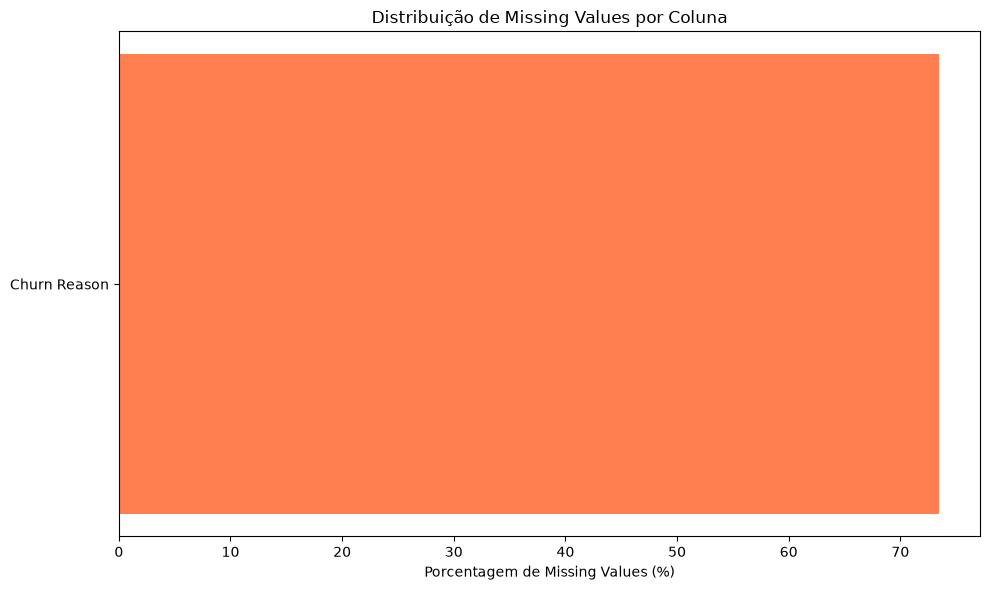

In [8]:
missing_values = pd.DataFrame(
    {
        "Coluna": df.columns,
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2),
    }
)

missing_values = missing_values[missing_values["Missing_Count"] > 0].sort_values(
    by="Missing_Percentage", ascending=False
)

if len(missing_values) > 0:
    print(missing_values)

    # Visualizar missing values
    plt.figure(figsize=(10, 6))
    plt.barh(
        missing_values["Coluna"], missing_values["Missing_Percentage"], color="coral"
    )
    plt.xlabel("Porcentagem de Missing Values (%)")
    plt.title("Distribuição de Missing Values por Coluna")
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum missing value detectado!")

### Análise da Variável Target

**Objetivo:** Entender a distribuição da variável alvo (balanceamento de classes)

=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===

Contagem:
target
0    5174
1    1869
Name: count, dtype: int64

Percentual:
Não Churn (0): 73.46%
Churn (1): 26.54%


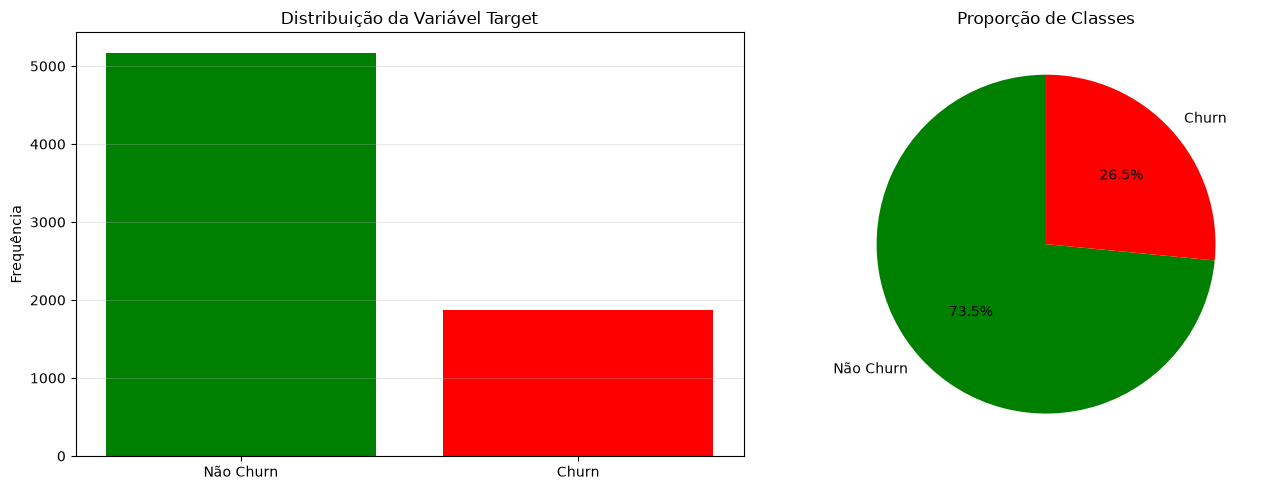


Ratio de balanceamento: 0.36
⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight.


In [9]:
# Renomear variável `Churn Value` para `target`
df.rename(columns={"Churn Value": "target"}, inplace=True)

print("=== DISTRIBUIÇÃO DA VARIÁVEL TARGET ===\n")
target_counts = df["target"].value_counts()
target_percentages = df["target"].value_counts(normalize=True) * 100

print("Contagem:")
print(target_counts)
print("\nPercentual:")
for idx, pct in target_percentages.items():
    label = "Não Churn" if idx == 0 else "Churn"
    print(f"{label} ({idx}): {pct:.2f}%")

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
axes[0].bar(["Não Churn", "Churn"], target_counts.values, color=["green", "red"])
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição da Variável Target")
axes[0].grid(axis="y", alpha=0.3)

# Gráfico de pizza
axes[1].pie(
    target_counts.values,
    labels=["Não Churn", "Churn"],
    autopct="%1.1f%%",
    colors=["green", "red"],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
plt.show()

# Verificar se há desbalanceamento
ratio = target_counts.min() / target_counts.max()
print(f"\nRatio de balanceamento: {ratio:.2f}")
if ratio < 0.5:
    print(
        "⚠️ Dataset desbalanceado! Considere usar técnicas como SMOTE ou class_weight."
    )
else:
    print("✓ Dataset razoavelmente balanceado.")

### Análise de Outliers

**Objetivo:** Identificar valores extremos que podem ser erros de medição ou casos especiais

**Métodos utilizados:**
- **Z-Score**: Identifica valores que estão a mais de 3 desvios padrão da média
- **Visualização**: Boxplots para identificação visual

C:\Users\Alves\AppData\Local\Temp\ipykernel_53476\2645828700.py:16: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  col_zscore = np.abs(stats.zscore(df[col].dropna()))


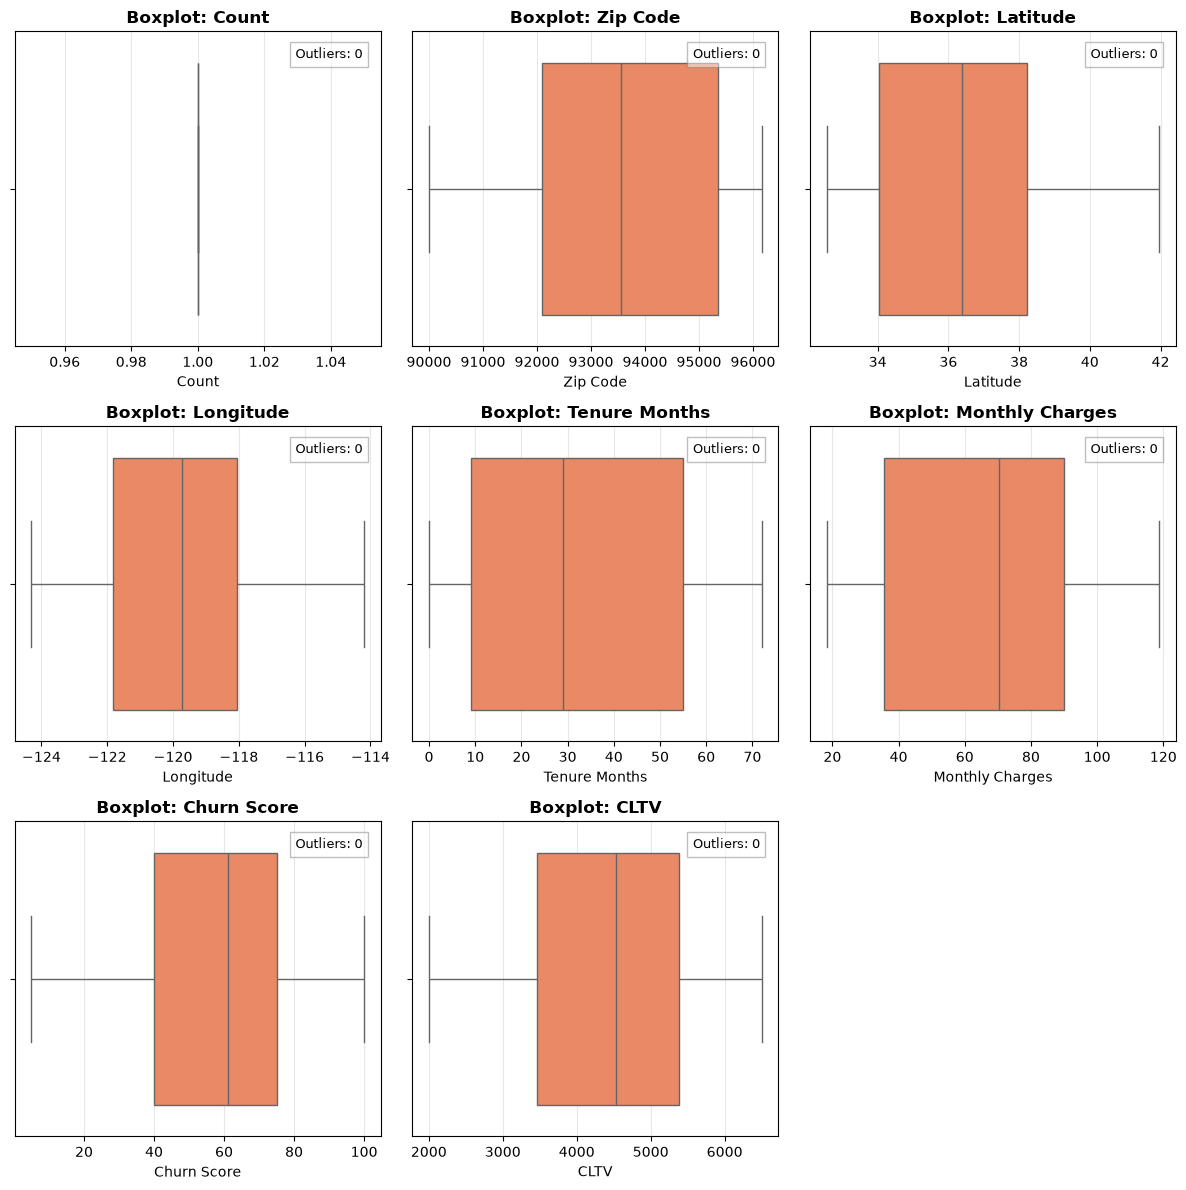

In [13]:
# Colunas numéricas (excluindo id e target)
numeric_cols = df.select_dtypes(include=[np.number]).columns
numeric_cols = numeric_cols.drop(['target'])

n = len(numeric_cols)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[idx], color='coral')
    axes[idx].set_title(f'Boxplot: {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].grid(axis='x', alpha=0.3)
    col_zscore = np.abs(stats.zscore(df[col].dropna()))
    outlier_count = (col_zscore > 3).sum()
    axes[idx].text(0.95, 0.95, f'Outliers: {outlier_count}', 
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top', horizontalalignment='right',
                   bbox=dict(facecolor='white', alpha=0.5, edgecolor='gray'))

for ax in axes[n:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()


### Análise de Anomalias e Valores Inválidos

In [20]:
#df.head(5)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [33]:
print("=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===\n")

# Verificações de consistência baseadas em conhecimento de domínio
anomalies = []

# 1. Gênero (deve estar entre 'Male' e 'Female' )
valid_genders = ['Male', 'Female']
bad_genders = df[~df['Gender'].isin(valid_genders)]['Gender'].unique()

if len(bad_genders) > 0:
    anomalies.append(f"Gênero inválido detectado: {list(bad_genders)}")

    
# 2. Internet Services validos
valid_internet_services = ['No', 'DSL', 'Fiber optic', 'Cable']
bad_internet_services = df[~df['Internet Service'].isin(valid_internet_services)]['Internet Service'].unique()

if len(bad_internet_services) > 0:
    anomalies.append(f"Serviço de internet inválido detectado: {list(bad_internet_services)}")


# 3. Contracts validos
valid_contracts = ['Month-to-month', 'One year', 'Two year']
bad_contracts = df[~df['Contract'].isin(valid_contracts)]['Contract'].unique()

if len(bad_contracts) > 0:
    anomalies.append(f"Contrato inválido detectado: {list(bad_contracts)}")


# 4. Payment Methods validos
valid_payment_methods = ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']
bad_payment_methods = df[~df['Payment Method'].isin(valid_payment_methods)]['Payment Method'].unique()

if len(bad_payment_methods) > 0:
    anomalies.append(f"Forma de pagamento inválida detectada: {list(bad_payment_methods)}")


# 5. Variáveis categóricas com valores fora do esperado
categorical_checks = {
    'Senior Citizen': ['Yes', 'No'],
    'Partner': ['Yes', 'No'],
    'Dependents': ['Yes', 'No'],
    'Phone Service': ['Yes', 'No'],
    'Multiple Lines': ['Yes', 'No', 'No phone service'],
    'Online Security': ['Yes', 'No', 'No internet service'],
    'Online Backup': ['Yes', 'No', 'No internet service'],
    'Device Protection': ['Yes', 'No', 'No internet service'],
    'Tech Support': ['Yes', 'No', 'No internet service'],
    'Streaming TV': ['Yes', 'No', 'No internet service'],
    'Streaming Movies': ['Yes', 'No', 'No internet service'],
    'Paperless Billing': ['Yes', 'No']
}

for col, valid_values in categorical_checks.items():
    if col in df.columns:
        invalid = df[~df[col].isin(valid_values) & df[col].notna()]
        if len(invalid) > 0:
            anomalies.append(f"{col}: {len(invalid)} valores inválidos")
            print(f"⚠️ {col}: {len(invalid)} valores fora do domínio esperado {valid_values}")

if len(anomalies) == 0:
    print("✓ Nenhuma anomalia óbvia detectada nas validações de domínio!")
else:
    print(f"\n📊 Total de tipos de anomalias detectadas: {len(anomalies)}")
    print(anomalies)

# Verificar duplicados
duplicates = df.duplicated().sum()
print(f"\n=== DUPLICADOS ===")
print(f"Registros duplicados: {duplicates}")
if duplicates > 0:
    print("⚠️ Considere remover ou investigar registros duplicados")

=== ANÁLISE DE ANOMALIAS E VALORES INVÁLIDOS ===

✓ Nenhuma anomalia óbvia detectada nas validações de domínio!

=== DUPLICADOS ===
Registros duplicados: 0
